<a href="https://colab.research.google.com/github/viktorbrojs-sys/BH_DS_Pro/blob/main/HW_2/AutoEncoder_latent_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import time
import os

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler

from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import reuters

In [2]:
# Загрузка текстовых данных

# убеждаемся, что корпус доступен
nltk.download('reuters')

start_time = time.time()

# получаем список всех документов
all_fileids = reuters.fileids()

# случайно выбираем n документов (не по порядку)
random.seed(42)
sample_fileids = random.sample(all_fileids, 1000)

# собираем тексты
texts = [" ".join(reuters.words(fid)) for fid in sample_fileids]

print(f"\nЗагружено текстов: {len(texts)}")
print(f"Время подготовки данных: {time.time() - start_time:.2f} сек\n")

# вывод первых 5 текстов для понимания структуры
for i, text in enumerate(texts[:5], 1):
    print(f"--- Текст {i} ---\n{text[:200]}...\n")


[nltk_data] Downloading package reuters to /root/nltk_data...



Загружено текстов: 1000
Время подготовки данных: 1.28 сек

--- Текст 1 ---
PAN ATLANTIC RE INC & lt ; PNRE > 4TH QTR NET Oper shr 15 cts vs 1 . 07 dlrs Oper net 372 , 000 vs 2 , 601 , 000 Year Oper shr 80 cts vs 61 cts Oper net 1 , 952 , 000 vs 1 , 491 , 000 NOTE : Net exclu...

--- Текст 2 ---
OECD SEES GERMAN GROWTH HIT BY LOW DOMESTIC DEMAND West German economic growth will slow to 1 . 5 pct this year from 2 . 4 pct in 1986 due to weak domestic demand and tougher competition from abroad ,...

--- Текст 3 ---
YUGOSLAVIA TO TENDER FOR 100 , 000 TONNES WHEAT Yugoslavia will tender April 14 for 100 , 000 tonnes of wheat , the U . S . Agriculture Department ' s Counselor in Belgrade said in a field report . Th...

--- Текст 4 ---
TRANSDUCER SYSTEMS INC YEAR Shr profit 12 cts vs loss 49 cts Net profit 117 , 000 vs loss 506 , 000 Revs 1 . 1 mln vs 1 . 2 mln Year Shr profit seven cts vs loss 89 cts Net profit 66 , 000 vs loss 921...

--- Текст 5 ---
SWISS MONEY MARKET PAPER YIELDS 3 . 286 

In [3]:
# Преобразование в TF-IDF

# создаём векторизатор
vectorizer = TfidfVectorizer(
    lowercase=True,         # приводим к нижнему регистру
    stop_words='english',   # удаляем стоп-слова
    max_features=1000,      # ограничиваем размер словаря
    min_df=3,               # слово должно встретиться минимум в 3 документах
    max_df=0.8              # игнорируем слишком частые слова
)

# получаем разреженную матрицу
X = vectorizer.fit_transform(texts)

print(f"\nTF-IDF размерность: {X.shape}")

# переводим в плотный формат (для подачи в нейросеть)
X = X.toarray()


TF-IDF размерность: (1000, 1000)


In [4]:
# Нормализация данных

# важно для стабильного обучения нейросети
scaler = MaxAbsScaler()
X = scaler.fit_transform(X)

# переводим в torch tensor
X = torch.tensor(X, dtype=torch.float32)

input_dim = X.shape[1]

In [5]:
# DataLoader (батчи)

batch_size = 32

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [6]:
# Определение автоэнкодера

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Энкодер: сжимает вход в компактное представление
        # Dropout добавлен для регуляризации и борьбы с переобучением
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, latent_dim)
        )

        # Декодер: восстанавливает исходные данные
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)             # сжатие
        x_recon = self.decoder(z)       # восстановление
        return x_recon

In [7]:
# Функция обучения модели

def train_model(latent_dim, epochs=150, lr=5e-4, dropout_rate=0.2, patience=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = Autoencoder(input_dim, latent_dim, dropout_rate).to(device)

    criterion = nn.MSELoss()                                              # функция потерь
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # снижаем lr при отсутствии прогресса (ReduceLROnPlateau)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )

    losses = []
    best_loss = float('inf')
    no_improve_count = 0

    train_start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch in dataloader:
            batch_x = batch[0].to(device)

            optimizer.zero_grad()

            # прямой проход
            output = model(batch_x)

            # считаем ошибку реконструкции
            loss = criterion(output, batch_x)

            # обратное распространение
            loss.backward()

            # Gradient clipping — предотвращает взрыв градиентов
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        scheduler.step(avg_loss)

        # Early stopping: останавливаем если нет улучшений
        if avg_loss < best_loss - 1e-6:
            best_loss = avg_loss
            no_improve_count = 0
        else:
            no_improve_count += 1


        print(
            f"Эпоха {epoch+1}/{epochs}, "
            f"loss: {avg_loss:.6f}, "
            f"lr: {optimizer.param_groups[0]['lr']:.2e}"
        )

        if no_improve_count >= patience:
            print(f"\nEarly stopping на эпохе {epoch+1}: нет улучшений {patience} эпох подряд.")
            break

    print(f"\nВремя обучения (latent_dim={latent_dim}): {time.time() - train_start:.2f} сек\n")

    return model, losses

In [8]:
# Обучение моделей

# малое скрытое пространство (агрессивное сжатие, высокая потеря информации)
model_5, loss_5 = train_model(latent_dim=5)

# для сравнения (умеренное сжатие, лучше сохраняет структуру данных)
model_50, loss_50 = train_model(latent_dim=50)

Эпоха 1/150, loss: 0.105313, lr: 5.00e-04
Эпоха 2/150, loss: 0.057244, lr: 5.00e-04
Эпоха 3/150, loss: 0.038290, lr: 5.00e-04
Эпоха 4/150, loss: 0.026411, lr: 5.00e-04
Эпоха 5/150, loss: 0.020182, lr: 5.00e-04
Эпоха 6/150, loss: 0.015958, lr: 5.00e-04
Эпоха 7/150, loss: 0.013135, lr: 5.00e-04
Эпоха 8/150, loss: 0.011569, lr: 5.00e-04
Эпоха 9/150, loss: 0.010759, lr: 5.00e-04
Эпоха 10/150, loss: 0.009902, lr: 5.00e-04
Эпоха 11/150, loss: 0.009455, lr: 5.00e-04
Эпоха 12/150, loss: 0.009226, lr: 5.00e-04
Эпоха 13/150, loss: 0.008622, lr: 5.00e-04
Эпоха 14/150, loss: 0.008443, lr: 5.00e-04
Эпоха 15/150, loss: 0.007904, lr: 5.00e-04
Эпоха 16/150, loss: 0.007756, lr: 5.00e-04
Эпоха 17/150, loss: 0.007374, lr: 5.00e-04
Эпоха 18/150, loss: 0.007389, lr: 5.00e-04
Эпоха 19/150, loss: 0.007251, lr: 5.00e-04
Эпоха 20/150, loss: 0.007091, lr: 5.00e-04
Эпоха 21/150, loss: 0.006934, lr: 5.00e-04
Эпоха 22/150, loss: 0.006897, lr: 5.00e-04
Эпоха 23/150, loss: 0.006580, lr: 5.00e-04
Эпоха 24/150, loss: 

In [9]:
# Получение латентных векторов

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# переводим модель в eval-режим: отключает Dropout и BatchNorm во время инференса
model_5.eval()
model_50.eval()

X_device = X.to(device)

with torch.no_grad():
    latent_vectors_5 = model_5.encoder(X_device).cpu().numpy()
    latent_vectors_50 = model_50.encoder(X_device).cpu().numpy()

print("\nПервые 5 латентных векторов (dim=5):")
for i, vec in enumerate(latent_vectors_5[:5]):
    print(f"{i}: {vec}")


Первые 5 латентных векторов (dim=5):
0: [-0.5767506  -0.00300252  0.19049138  0.90430707  0.07030268]
1: [-0.03839237  0.85088015 -1.0599228  -0.25613806  0.16472854]
2: [-0.18997625 -0.26182777 -0.3508799   0.4022021   0.59183776]
3: [-0.04385256  0.09468218  0.26138672  0.68343234 -0.18165676]
4: [ 0.1798116   0.15064792 -0.25251487 -0.02779545 -0.09182319]


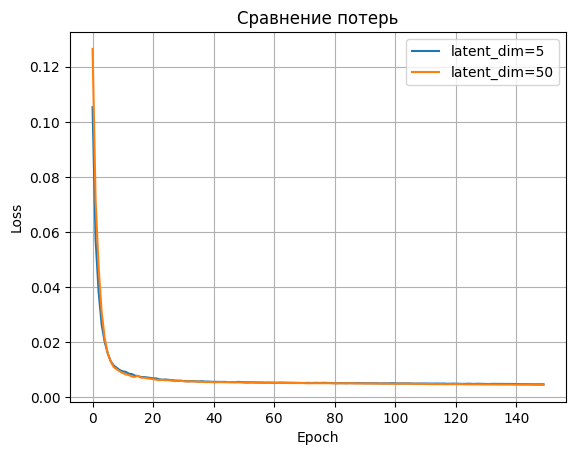

In [10]:
# Визуализация функции потерь

os.makedirs("results", exist_ok=True)

plt.figure()
plt.plot(loss_5, label="latent_dim=5")
plt.plot(loss_50, label="latent_dim=50")

plt.legend()
plt.title("Cравнение потерь")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

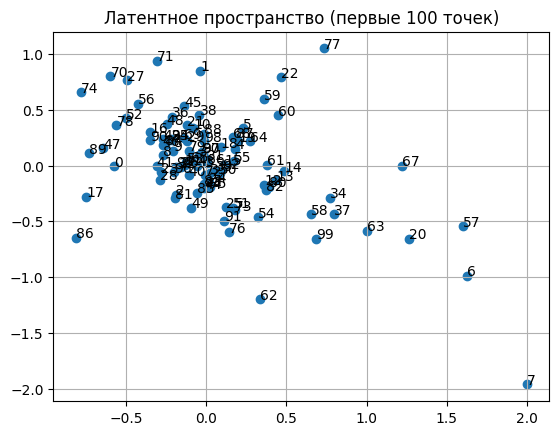

In [11]:
# Визуализация латентного пространства (dim=5 -> первые 2 координаты)

sample_size = 100

plt.figure()

plt.scatter(
    latent_vectors_5[:sample_size, 0],
    latent_vectors_5[:sample_size, 1]
)

# подписи точек (для наглядности)
for i in range(sample_size):
    plt.annotate(str(i), (
        latent_vectors_5[i, 0],
        latent_vectors_5[i, 1]
    ))

plt.title(f"Латентное пространство (первые {sample_size} точек)")
plt.grid()
plt.show()

In [12]:
# Сравнение исходного и восстановленного "текста" (model_5)
feature_names = vectorizer.get_feature_names_out()

def top_words(vector, feature_names, top_n=10):
    indices = np.argsort(vector)[-top_n:][::-1]
    return [feature_names[i] for i in indices]

with torch.no_grad():
    device = next(model_5.parameters()).device

    recon_5 = model_5(X.to(device)).cpu().numpy()
    original = X.cpu().numpy()

print("\nСравнение исходных и восстановленных текстов (по ключевым словам):\n")

for i in range(5):
    orig_words = top_words(original[i], feature_names)
    recon_words = top_words(recon_5[i], feature_names)

    print(f"--- Текст {i} ---")
    print("Оригинал (топ слова):     ", orig_words)
    print("Восстановленный (топ):   ", recon_words)
    print()


Сравнение исходных и восстановленных текстов (по ключевым словам):

--- Текст 0 ---
Оригинал (топ слова):      ['excludes', '000', 'net', 'oper', 'dlrs', 'vs', '61', 'year', 'gains', 'shr']
Восстановленный (топ):    ['net', 'vs', 'dlrs', 'shr', '000', 'cts', 'note', 'mln', 'oper', 'qtr']

--- Текст 1 ---
Оригинал (топ слова):      ['oecd', 'german', 'west', 'economy', '1988', 'longer', 'year', 'growth', 'pct', 'domestic']
Восстановленный (топ):    ['pct', 'growth', 'year', 'said', 'government', 'economy', 'expected', 'rate', 'economic', 'economists']

--- Текст 2 ---
Оригинал (топ слова):      ['100', 'wheat', 'harvest', 'considered', 'result', 'used', 'import', 'tender', 'subject', 'imports']
Восстановленный (топ):    ['tonnes', 'said', 'agriculture', 'harvest', '000', 'crop', 'wheat', 'department', 'export', 'usda']

--- Текст 3 ---
Оригинал (топ слова):      ['000', '89', '49', 'revs', 'profit', 'vs', 'cts', 'year', 'loss', 'shr']
Восстановленный (топ):    ['vs', 'net', 'revs', 'sh

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

with torch.no_grad():
    device_5 = next(model_5.parameters()).device
    device_50 = next(model_50.parameters()).device

    # реконструкции
    recon_5 = model_5(X.to(device_5)).cpu().numpy()
    recon_50 = model_50(X.to(device_50)).cpu().numpy()

    original = X.cpu().numpy()

# cosine similarity для каждого текста
cos_sim_5 = cosine_similarity(original, recon_5).diagonal()
cos_sim_50 = cosine_similarity(original, recon_50).diagonal()

print(f"Средняя cosine similarity (latent_dim=5):  {cos_sim_5.mean():.4f}")
print(f"Средняя cosine similarity (latent_dim=50): {cos_sim_50.mean():.4f}")

Средняя cosine similarity (latent_dim=5):  0.4937
Средняя cosine similarity (latent_dim=50): 0.5643


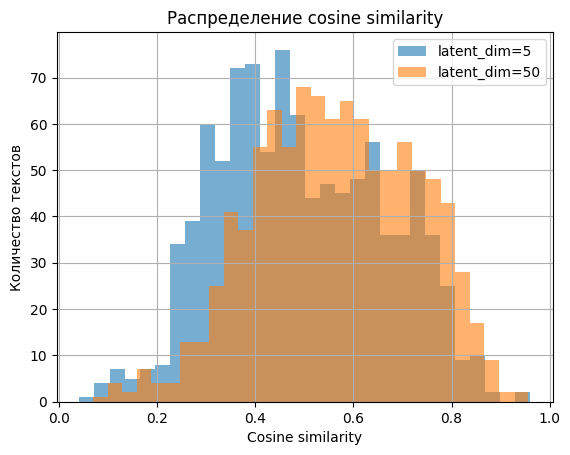

In [14]:
plt.figure()

plt.hist(cos_sim_5, bins=30, alpha=0.6, label="latent_dim=5")
plt.hist(cos_sim_50, bins=30, alpha=0.6, label="latent_dim=50")

plt.legend()
plt.title("Распределение cosine similarity")
plt.xlabel("Cosine similarity")
plt.ylabel("Количество текстов")
plt.grid()
plt.show()